<!-- # Copyright (c) 2026 takotime808 -->
# Conformal Prediction with multioutreg

This notebook demonstrates **conformal prediction** -- a distribution-free method for constructing prediction intervals with finite-sample coverage guarantees.

Unlike Gaussian-based confidence intervals (`y_pred ± z * y_std`), conformal prediction:
- Makes **no distributional assumptions** about the errors
- Works with **any** sklearn-compatible regressor
- Provides **guaranteed coverage**: P(Y ∈ [lower, upper]) ≥ 1 - α

## Contents
1. Split Conformal Prediction
2. CV+ Conformal Prediction
3. Adaptive (Locally-Varying) Intervals
4. Gaussian vs Conformal Coverage Comparison
5. Multi-Output Example
6. Conformal Metrics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import LinearRegression

from multioutreg.conformal import (
    SplitConformalPredictor,
    CVPlusConformalPredictor,
    conformal_summary,
)
from multioutreg.figures.conformal_plots import (
    plot_conformal_intervals,
    plot_conformal_intervals_ordered,
    plot_conformal_vs_gaussian,
    plot_conditional_coverage,
)

In [2]:
# Generate synthetic data
X, y = make_regression(n_samples=500, n_features=5, noise=15, random_state=42)
X_train, X_test = X[:400], X[400:]
y_train, y_test = y[:400], y[400:]

## 1. Split Conformal Prediction

Split conformal is the simplest method: it splits data into train and calibration sets internally, fits the model on the train portion, and uses calibration residuals to set interval width.

In [3]:
cp_split = SplitConformalPredictor(
    RandomForestRegressor(n_estimators=100, random_state=0),
    calibration_size=0.2,
    random_state=42,
)
cp_split.fit(X_train, y_train)

y_pred, y_lower, y_upper = cp_split.predict(X_test, alpha=0.1)

coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
mean_width = np.mean(y_upper - y_lower)
print(f"Empirical coverage: {coverage:.1%} (target: 90%)")
print(f"Mean interval width: {mean_width:.2f}")

Empirical coverage: 90.0% (target: 90%)
Mean interval width: 113.94


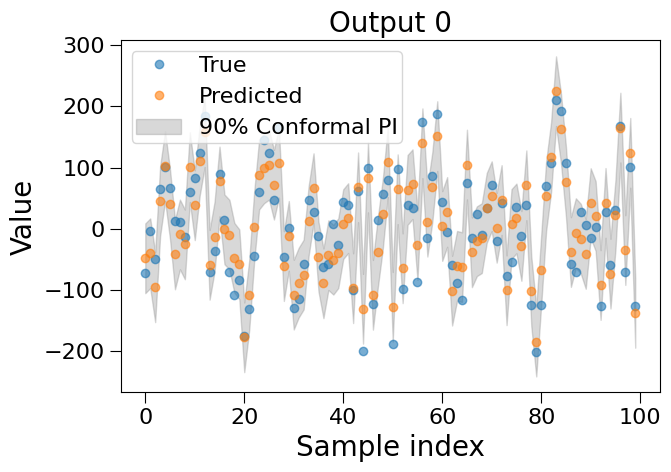

In [4]:
plot_conformal_intervals(y_test, y_lower, y_upper, y_pred=y_pred, alpha=0.1)

## 2. CV+ Conformal Prediction

CV+ uses K-fold cross-validation to avoid wasting data on a separate calibration set. Better for small datasets.

In [5]:
cp_cvplus = CVPlusConformalPredictor(
    RandomForestRegressor(n_estimators=100, random_state=0),
    n_folds=5,
    random_state=42,
)
cp_cvplus.fit(X_train, y_train)

y_pred_cv, y_lower_cv, y_upper_cv = cp_cvplus.predict(X_test, alpha=0.1)

coverage_cv = np.mean((y_test >= y_lower_cv) & (y_test <= y_upper_cv))
mean_width_cv = np.mean(y_upper_cv - y_lower_cv)
print(f"CV+ Empirical coverage: {coverage_cv:.1%} (target: 90%)")
print(f"CV+ Mean interval width: {mean_width_cv:.2f}")
print(f"\nSplit conformal width: {mean_width:.2f}")
print(f"CV+ width:             {mean_width_cv:.2f}")

CV+ Empirical coverage: 98.0% (target: 90%)
CV+ Mean interval width: 123.71

Split conformal width: 113.94
CV+ width:             123.71


## 3. Adaptive Conformal Intervals

When the underlying model provides uncertainty estimates (e.g., Gaussian Process), adaptive conformal uses **normalized residuals** to produce intervals that are wider where the model is uncertain and narrower where it is confident -- while still maintaining the coverage guarantee.

In [6]:
# Use a smaller dataset for GP (computational cost)
X_gp, y_gp = make_regression(n_samples=200, n_features=3, noise=10, random_state=42)
X_gp_train, X_gp_test = X_gp[:150], X_gp[150:]
y_gp_train, y_gp_test = y_gp[:150], y_gp[150:]

# Non-adaptive (constant-width) conformal
cp_const = SplitConformalPredictor(
    GaussianProcessRegressor(random_state=0),
    adaptive=False,
    random_state=42,
)
cp_const.fit(X_gp_train, y_gp_train)
_, y_lower_const, y_upper_const = cp_const.predict(X_gp_test, alpha=0.1)

# Adaptive conformal
cp_adapt = SplitConformalPredictor(
    GaussianProcessRegressor(random_state=0),
    adaptive=True,
    random_state=42,
)
cp_adapt.fit(X_gp_train, y_gp_train)
_, y_lower_adapt, y_upper_adapt = cp_adapt.predict(X_gp_test, alpha=0.1)

print(f"Constant-width interval std: {(y_upper_const - y_lower_const).std():.3f}")
print(f"Adaptive interval std:       {(y_upper_adapt - y_lower_adapt).std():.3f}")
print("\nAdaptive intervals vary in width based on model uncertainty.")

Constant-width interval std: 0.000
Adaptive interval std:       4681.978

Adaptive intervals vary in width based on model uncertainty.


## 4. Gaussian vs Conformal Coverage Comparison

This comparison shows that Gaussian confidence intervals (y_pred ± z * y_std) can be miscalibrated, while conformal intervals achieve the target coverage.

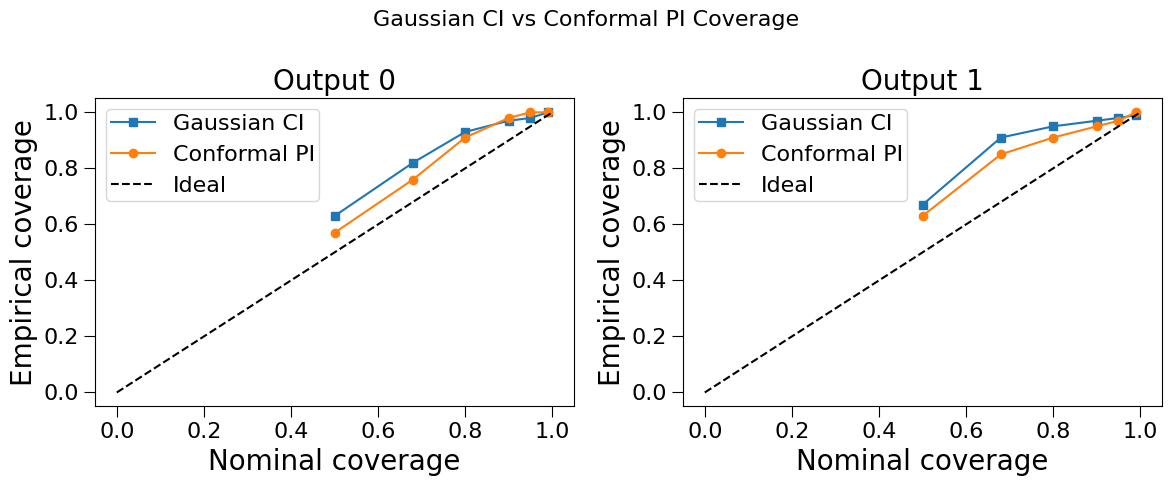

In [7]:
# Fit RF and get predictions with std
from sklearn.multioutput import MultiOutputRegressor

X_mo, y_mo = make_regression(
    n_samples=500, n_features=5, n_targets=2, noise=15, random_state=42
)
X_mo_train, X_mo_test = X_mo[:400], X_mo[400:]
y_mo_train, y_mo_test = y_mo[:400], y_mo[400:]

rf = RandomForestRegressor(n_estimators=100, random_state=0)
mo_rf = MultiOutputRegressor(rf)
mo_rf.fit(X_mo_train, y_mo_train)

# Get predictions and std from RF ensemble
y_pred_mo = mo_rf.predict(X_mo_test)
stds = []
for est in mo_rf.estimators_:
    preds = np.array([tree.predict(X_mo_test) for tree in est.estimators_])
    stds.append(preds.std(axis=0))
y_std_mo = np.column_stack(stds)

# Fit conformal on same data
cp_mo = SplitConformalPredictor(
    RandomForestRegressor(n_estimators=100, random_state=0),
    random_state=42,
)
cp_mo.fit(X_mo_train, y_mo_train)

plot_conformal_vs_gaussian(
    y_mo_test, y_pred_mo, y_std_mo, cp_mo.residuals_,
    output_names=["Output 0", "Output 1"],
)

## 5. Multi-Output Example with Ordered Intervals

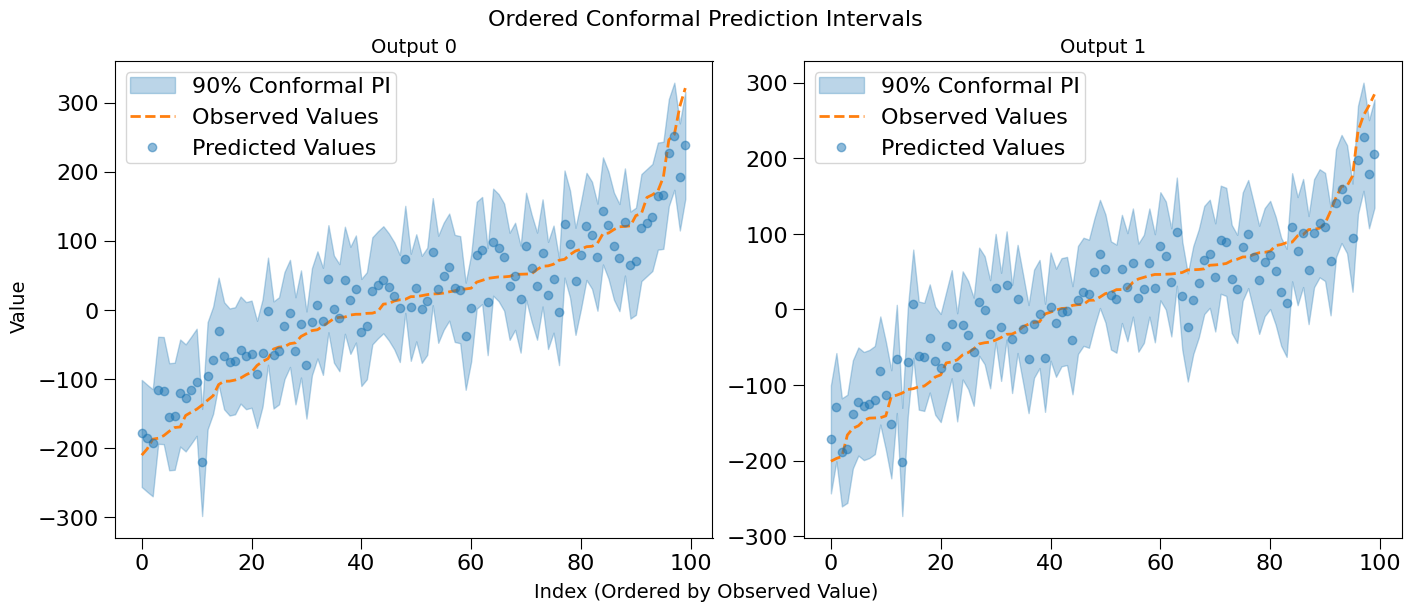

In [8]:
y_pred_mo2, y_lower_mo, y_upper_mo = cp_mo.predict(X_mo_test, alpha=0.1)

plot_conformal_intervals_ordered(
    y_mo_test, y_lower_mo, y_upper_mo,
    y_pred=y_pred_mo2,
    output_names=["Output 0", "Output 1"],
    alpha=0.1,
)

## 6. Conformal Metrics Summary

In [9]:
summary = conformal_summary(
    y_mo_test, y_lower_mo, y_upper_mo, alpha=0.1,
    output_names=["Output 0", "Output 1"],
)
summary

,output,nominal_coverage,coverage,coverage_gap,mean_width,median_width,n_samples
0,Output 0,0.9,0.97,0.07,155.144869,155.144869,100
1,Output 1,0.9,0.93,0.03,143.058341,143.058341,100


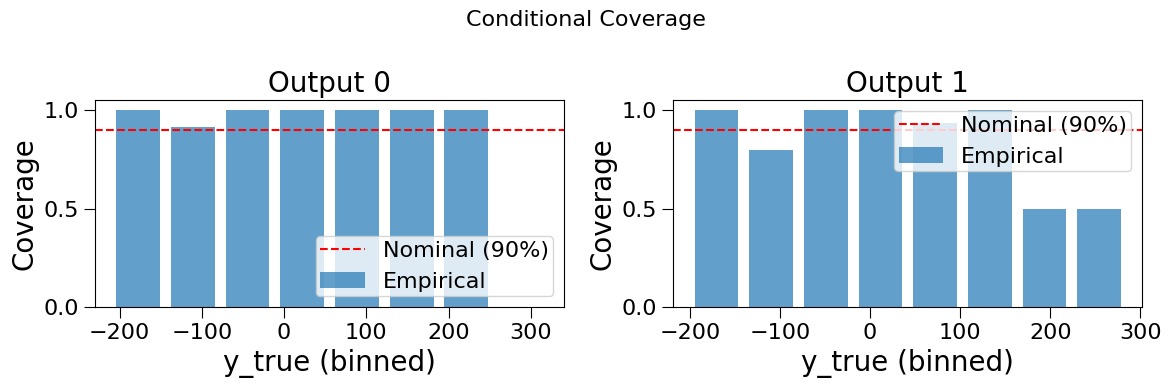

In [10]:
# Conditional coverage: is coverage uniform across the response range?
plot_conditional_coverage(
    y_mo_test, y_lower_mo, y_upper_mo,
    n_bins=8,
    output_names=["Output 0", "Output 1"],
    alpha=0.1,
)